# Análisis de series de Siempo sobre demanda de pasajeros aéreos Internacionales

## Introducción

El transporte aéreo internacional experimentó un crecimiento acelerado durante la posguerra. Con el auge de los vuelos comerciales en los años 50, las aerolíneas necesitaban anticipar la demanda para planificar capacidad operativa y flota.
Por esto, decidimos aplicar dsitintos modelos vistos en clase para entender cuál es el que mejor aplica a este problema.

**Pregunta de investigación:**

¿Qué modelo estadístico —Holt-Winters, AutoARIMA o SARIMA— predice con mayor precisión la demanda mensual de pasajeros aéreos internacionales para los últimos 2 años de la serie (1959–1960)?

Para responderla se compararán tres modelos de complejidad creciente, todos entrenados sobre el período 1949–1958 y evaluados sobre el período de prueba 1959–1960 mediante las métricas RMSE y MAE.

**Hipótesis de trabajo:** Los modelos que incorporan explícitamente estacionalidad multiplicativa, donde la amplitud del ciclo anual crece proporcionalmente con el nivel de la serie, superarán a los que asumen componentes aditivos.

In [ ]:
# =============================================================================
# Imports
# =============================================================================
import warnings
import os
import shutil

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

warnings.filterwarnings("ignore")

# --- EDA ---
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

# --- Modelos ---
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, mean_absolute_error
from pmdarima import auto_arima

# --- Comparación ---
from IPython.display import display

/Users/cespinola/Desktop/Maestría/13_Analisis de series de tiempo/.venv_tp/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/cespinola/Desktop/Maestría/13_Analisis de series de tiempo/.venv_tp/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Descarga del Dataset

In [2]:
print("Iniciando la descarga del dataset 'Air Passengers'...")
# 1. Descargar la última versión desde Kaggle (se descarga en una carpeta caché del sistema)
path_cache = kagglehub.dataset_download("chirag19/air-passengers")

print(f"Dataset descargado en caché: {path_cache}")

# 2. Mover archivo a nuestra carpeta de trabajo actual
archivo_csv = "AirPassengers.csv"
ruta_origen = os.path.join(path_cache, archivo_csv)
ruta_destino = os.path.join(os.getcwd(), archivo_csv)

Iniciando la descarga del dataset 'Air Passengers'...
Dataset descargado en caché: /Users/cespinola/.cache/kagglehub/datasets/chirag19/air-passengers/versions/1


In [3]:
if os.path.exists(ruta_origen):
    shutil.copy(ruta_origen, ruta_destino)
    print(f"\n¡Éxito! El archivo se ha copiado a tu carpeta actual:")
    print(f"-> {ruta_destino}")
else:
    print(f"\nNo se encontró el archivo {archivo_csv} en la ruta descargada.")
    print("Revisa la carpeta caché manualmente.")


¡Éxito! El archivo se ha copiado a tu carpeta actual:
-> /Users/cespinola/Desktop/Maestría/13_Analisis de series de tiempo/TPs/TP2/Analisis-de-Series-de-Tiempo-main/AirPassengers.csv


In [4]:
# Cargar el dataset
try:
    df = pd.read_csv("AirPassengers.csv")
    print("\nDataset cargado exitosamente.")
except FileNotFoundError:
    print("Error: No se encontró 'AirPassengers.csv'. Asegúrate de haber ejecutado el script 01.")
    exit()


Dataset cargado exitosamente.


## 2. Descripción de los Datos

### Origen

El dataset **AirPassengers** registra mensualmente el número de pasajeros de aerolíneas internacionales entre enero de 1949 y diciembre de 1960. Fue publicado originalmente por Box & Jenkins (1976) en *Time Series Analysis: Forecasting and Control*, y es uno de los benchmarks de referencia en el campo. La versión utilizada fue descargada de Kaggle (`chirag19/air-passengers`).

### Atributos

| Columna original | Nombre en análisis | Tipo | Rango | Descripción |
|---|---|---|---|---|
| `Month` | `fecha` | `datetime` (índice temporal) | ene 1949 – dic 1960 | Año y mes de la observación |
| `#Passengers` | `pasajeros` | `int64` | 104 – 622 | Pasajeros mensuales (en miles) |

**Dimensiones:** 144 observaciones (12 años × 12 meses), sin valores nulos ni duplicados.

### Propiedades estadísticas relevantes

El EDA a continuación revela tres características que determinan la configuración de los modelos:

1. **Tendencia creciente:** el volumen mensual pasó de ~112 mil pasajeros (ene 1949) a ~432 mil (dic 1960).
2. **Estacionalidad anual (s = 12):** picos recurrentes en julio–agosto por el verano del hemisferio norte, visibles en el boxplot mensual.
3. **Estacionalidad multiplicativa:** la amplitud de los picos estacionales crece proporcionalmente con el nivel de la serie. Holt-Winters puede modelar esto directamente con `seasonal='mul'`. SARIMA y AutoARIMA son modelos lineales (aditivos por naturaleza); para series multiplicativas, aplicar una transformación logarítmica previa es la práctica estándar, esto se probará en la sección 5.

In [5]:
print(df.head())

     Month  #Passengers
0  1949-01          112
1  1949-02          118
2  1949-03          132
3  1949-04          129
4  1949-05          121


In [6]:
print("INFORMACIÓN GENERAL DEL DATASET")
print()
df.info()

INFORMACIÓN GENERAL DEL DATASET

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Month        144 non-null    object
 1   #Passengers  144 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.4+ KB


In [7]:
print("REVISIÓN DE NULOS")
print()
nulos = df.isnull().sum()
print(nulos)

if nulos.sum() == 0:
    print("-> ¡Excelente! El dataset está limpio, no hay valores nulos.")
else:
    print("-> ¡Atención! Se encontraron valores nulos.")

REVISIÓN DE NULOS

Month          0
#Passengers    0
dtype: int64
-> ¡Excelente! El dataset está limpio, no hay valores nulos.


In [8]:
print("REVISIÓN DE DUPLICADOS")
print()
duplicados = df.duplicated().sum()
print(f"Filas duplicadas encontradas: {duplicados}")

REVISIÓN DE DUPLICADOS

Filas duplicadas encontradas: 0


*Preparación clave para Series de Tiempo:*

In [9]:
# TRANSFORMACIÓN DE FECHAS 
# Renombramos las columnas para que no tengan caracteres raros como '#'
df.rename(columns={'Month': 'fecha', '#Passengers': 'pasajeros'}, inplace=True)

# Convertimos el texto (ej: '1949-01') a un formato de tiempo matemático
df['fecha'] = pd.to_datetime(df['fecha'])

# En Series de Tiempo, la fecha SIEMPRE debe ser el índice del DataFrame
df.set_index('fecha', inplace=True)

print("\n--- ESTRUCTURA FINAL (LISTA PARA MODELOS) ---")
print(df.head())
print(f"\nTipo de índice actual: {type(df.index)}")


--- ESTRUCTURA FINAL (LISTA PARA MODELOS) ---
            pasajeros
fecha                
1949-01-01        112
1949-02-01        118
1949-03-01        132
1949-04-01        129
1949-05-01        121

Tipo de índice actual: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>


*Visualizaciones*

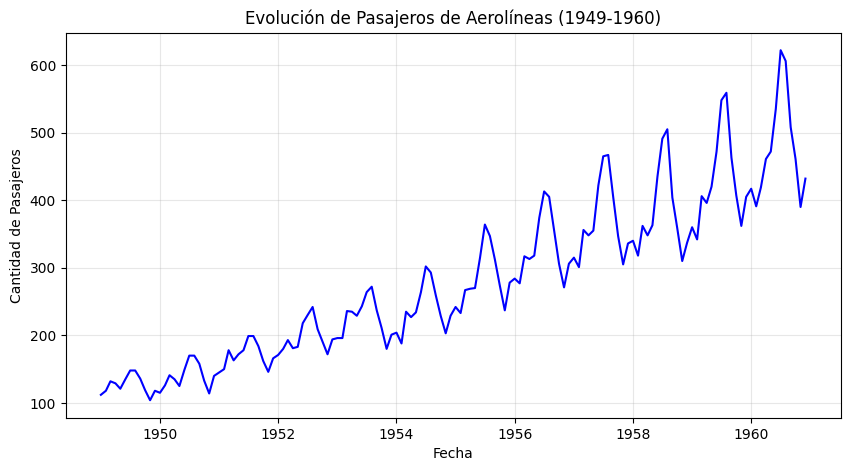

In [10]:
# 1. Gráfico principal (Para ver Tendencia a ojo)
plt.figure(figsize=(10, 5))
plt.plot(df.index, df['pasajeros'], color='blue')
plt.title('Evolución de Pasajeros de Aerolíneas (1949-1960)')
plt.xlabel('Fecha')
plt.ylabel('Cantidad de Pasajeros')
plt.grid(True, alpha=0.3)
plt.show()

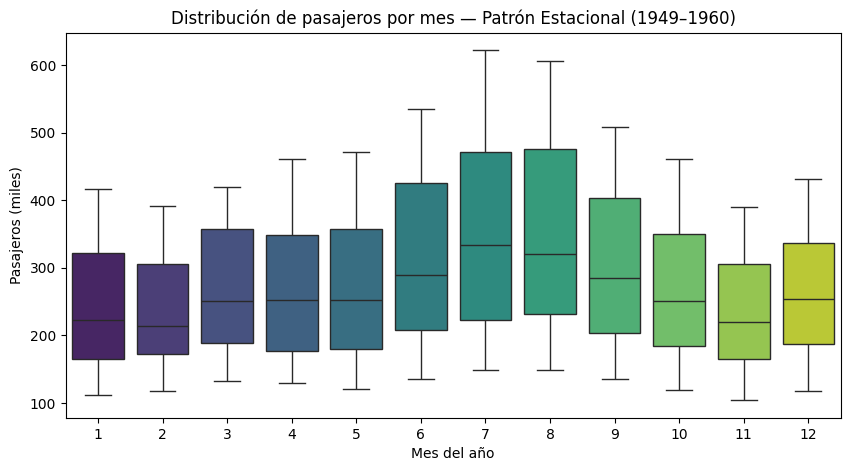

In [11]:
# El boxplot muestra la distribución de pasajeros para cada mes a lo largo de los 12 años.
# Se observa que existe una jerarquía estacional consistente: julio y agosto tienen
# medianas más altas, confirmando el ciclo anual.
df['mes'] = df.index.month
plt.figure(figsize=(10, 5))
sns.boxplot(x='mes', y='pasajeros', data=df, palette='viridis')
plt.title('Distribución de pasajeros por mes — Patrón Estacional (1949–1960)')
plt.xlabel('Mes del año')
plt.ylabel('Pasajeros (miles)')
plt.show()

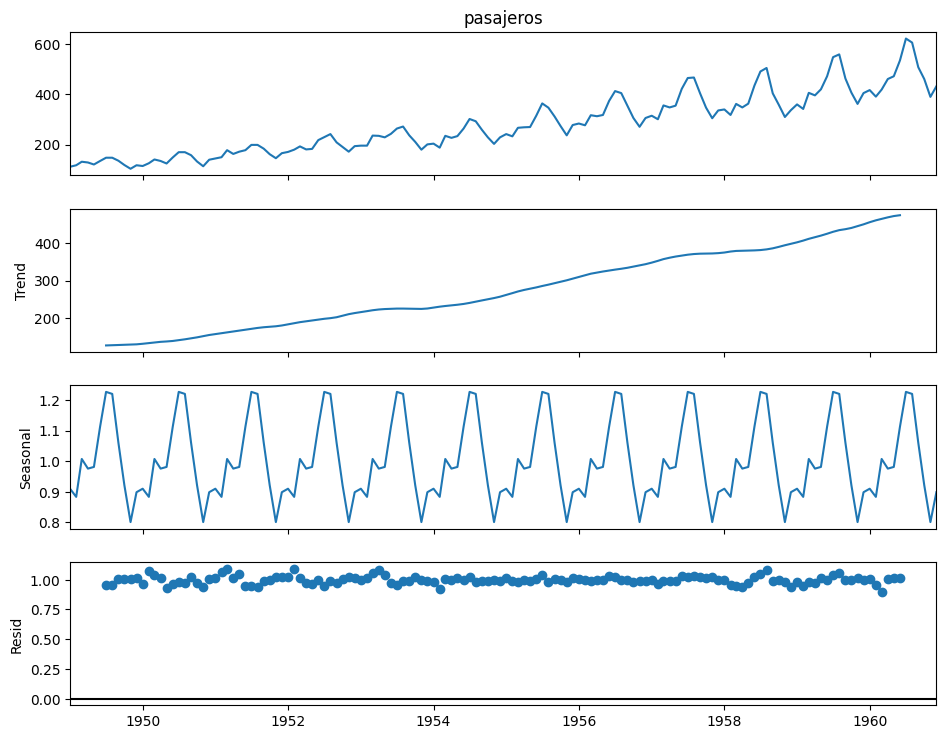

In [12]:
# 3. Descomposición de la Serie de Tiempo
# Separamos la gráfica en Tendencia, Estacionalidad y Residuos (Ruido)
descomposicion = seasonal_decompose(df['pasajeros'], model='multiplicative')
fig = descomposicion.plot()
fig.set_size_inches(10, 8)
plt.show()

In [13]:
# Limpiamos la columna extra que creamos solo para graficar
df.drop(columns=['mes'], inplace=True)

---

### Preparación: Partición Train / Test

Se define la partición temporal que comparten los tres modelos. La división respeta el orden cronológico de la serie para evitar *data leakage*.

In [14]:
# Partición Train / Test — compartida por los tres modelos
# df ya está preparado en la sección EDA (índice temporal, columna 'pasajeros')
train_c = df.iloc[:-24]   # ene 1949 – dic 1958  (120 observaciones)
test_c  = df.iloc[-24:]   # ene 1959 – dic 1960  (24 observaciones)

print(f"Train: {len(train_c)} obs  "
      f"({train_c.index[0].strftime('%b %Y')} – {train_c.index[-1].strftime('%b %Y')})")
print(f"Test:  {len(test_c)} obs  "
      f"({test_c.index[0].strftime('%b %Y')} – {test_c.index[-1].strftime('%b %Y')})")

Train: 120 obs  (Jan 1949 – Dec 1958)
Test:  24 obs  (Jan 1959 – Dec 1960)


---

### Prueba de Estacionariedad (Dickey-Fuller Aumentada)

Antes de construir los modelos, verificamos si la serie es **estacionaria** — condición que requiere media y varianza constantes en el tiempo.

La **Prueba ADF** contrasta H₀: raíz unitaria (no estacionaria) vs. H₁: estacionaria. Un p-value < 0.05 lleva a rechazar H₀ y confirma estacionariedad. El resultado guía la elección de los órdenes de diferenciación `d` y `D`.

In [15]:
resultado_adf = adfuller(df['pasajeros'])
print("=== Prueba de Dickey-Fuller Aumentada ===")
print(f"Estadístico ADF : {resultado_adf[0]:.4f}")
print(f"p-value         : {resultado_adf[1]:.4f}")
print("Valores críticos:")
for key, val in resultado_adf[4].items():
    print(f"  {key}: {val:.4f}")
conclusion = "ESTACIONARIA" if resultado_adf[1] < 0.05 else "NO ESTACIONARIA"
print(f"\n→ Conclusión: la serie es {conclusion} (p-value {'<' if resultado_adf[1] < 0.05 else '>'} 0.05)")
if resultado_adf[1] >= 0.05:
    print("→ Los modelos deben incorporar diferenciación (d ≥ 1, D ≥ 1).")

=== Prueba de Dickey-Fuller Aumentada ===
Estadístico ADF : 0.8154
p-value         : 0.9919
Valores críticos:
  1%: -3.4817
  5%: -2.8840
  10%: -2.5788

→ Conclusión: la serie es NO ESTACIONARIA (p-value > 0.05)
→ Los modelos deben incorporar diferenciación (d ≥ 1, D ≥ 1).


## 3. Descripción de los Modelos

Se construyen tres modelos en orden de complejidad conceptual creciente. Todos comparten la misma partición temporal para que las métricas sean directamente comparables:

| Conjunto | Período | Observaciones |
|---|---|---|
| **Train** | Ene 1949 – Dic 1958 | 120 (83 %) |
| **Test** | Ene 1959 – Dic 1960 | 24 (17 %) |

---

### Modelo 1: Holt-Winters

>No requiere pruebas de estacionariedad ni selección de órdenes ARIMA.

**Descripción:**  
Holt-Winters extiende el suavizado exponencial modelando tres componentes de la serie mediante ecuaciones de actualización con parámetros α (nivel), β (tendencia) y γ (estacionalidad). En cada paso actualiza su estimación ponderando las observaciones recientes con más peso que las pasadas.

**Justificación de uso:** La opción `seasonal='mul'` modela la amplitud del ciclo estacional de forma proporcional al nivel — exactamente el patrón que muestra AirPassengers.

#### Configuración y selección de parámetros

Los parámetros se fijaron con base en el EDA:
- `trend='add'` → tendencia lineal creciente
- `seasonal='mul'` → estacionalidad multiplicativa (amplitud ∝ nivel de la serie)
- `seasonal_periods=12` → ciclo anual
- `optimized=True` → α, β, γ estimados automáticamente por máxima verosimilitud

#### Entrenamiento

In [16]:
modelo_hw = ExponentialSmoothing(
    train_c['pasajeros'],
    trend='add',
    seasonal='mul',
    seasonal_periods=12
)
resultado_hw = modelo_hw.fit(optimized=True)
pred_hw = resultado_hw.forecast(steps=24)
pred_hw.index = test_c.index

rmse_hw = np.sqrt(mean_squared_error(test_c['pasajeros'], pred_hw))
mae_hw  = mean_absolute_error(test_c['pasajeros'], pred_hw)

print("=== Holt-Winters — entrenado ===")
print(f"α (nivel)      = {resultado_hw.params['smoothing_level']:.4f}")
print(f"β (tendencia)  = {resultado_hw.params['smoothing_trend']:.4f}")
print(f"γ (estacional) = {resultado_hw.params['smoothing_seasonal']:.4f}")
print(f"RMSE (test) = {rmse_hw:.2f}  |  MAE (test) = {mae_hw:.2f}")

=== Holt-Winters — entrenado ===
α (nivel)      = 0.3642
β (tendencia)  = 0.0000
γ (estacional) = 0.6358
RMSE (test) = 32.49  |  MAE (test) = 28.98


/Users/cespinola/Desktop/Maestría/13_Analisis de series de tiempo/.venv_tp/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


#### Visualización: Ajuste en datos de entrenamiento (Train)

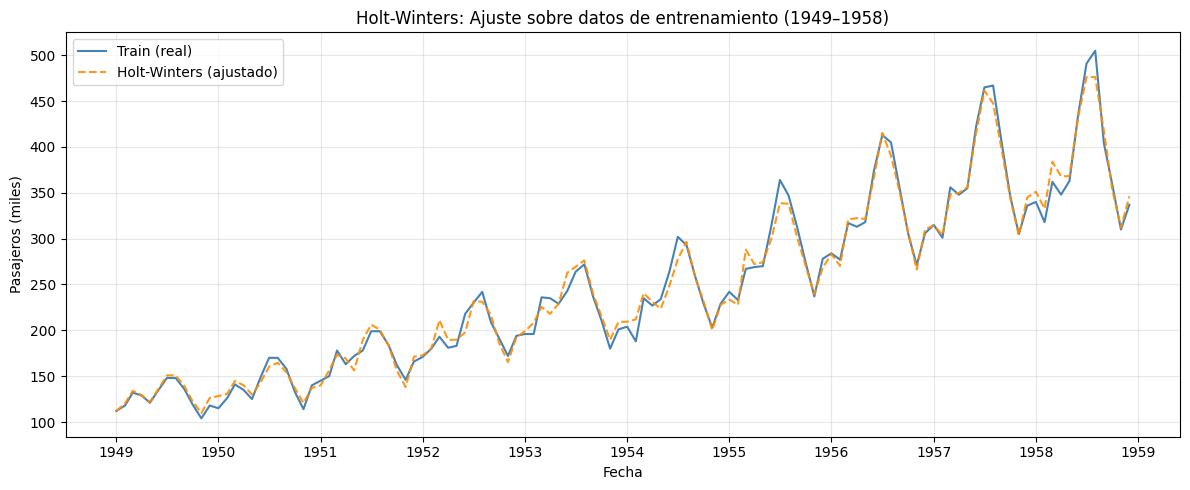

In [17]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(train_c.index, train_c['pasajeros'],
        label='Train (real)', color='steelblue', linewidth=1.5)
ax.plot(train_c.index, resultado_hw.fittedvalues,
        label='Holt-Winters (ajustado)', color='darkorange', linestyle='--', alpha=0.9)
ax.set_title('Holt-Winters: Ajuste sobre datos de entrenamiento (1949–1958)')
ax.set_xlabel('Fecha'); ax.set_ylabel('Pasajeros (miles)')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

#### Visualización: Predicciones sobre período de prueba (Test)

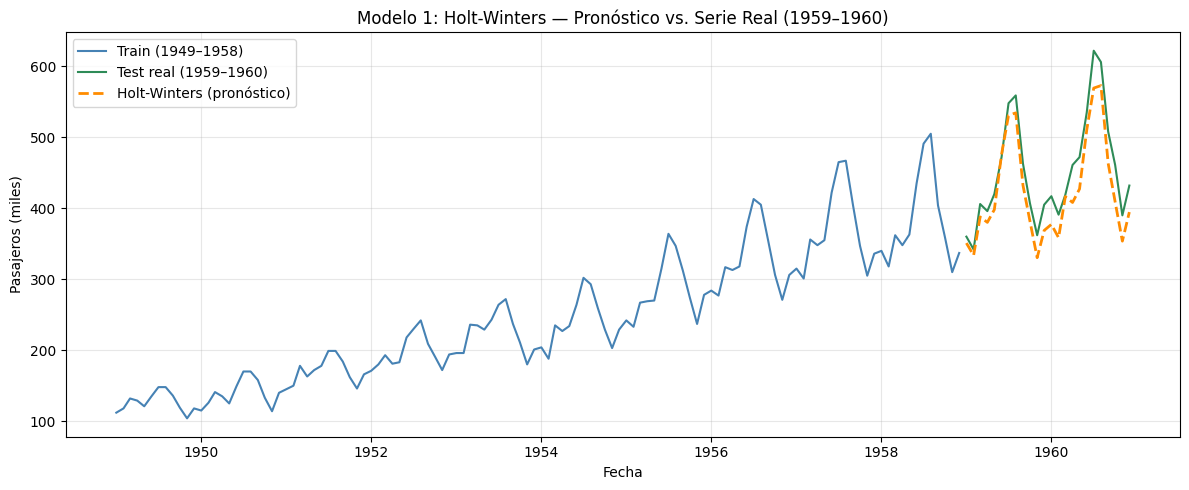

In [18]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(train_c.index, train_c['pasajeros'], label='Train (1949–1958)', color='steelblue')
ax.plot(test_c.index,  test_c['pasajeros'],  label='Test real (1959–1960)', color='seagreen')
ax.plot(pred_hw.index, pred_hw,
        label='Holt-Winters (pronóstico)', color='darkorange', linestyle='--', linewidth=2)
ax.set_title('Modelo 1: Holt-Winters — Pronóstico vs. Serie Real (1959–1960)')
ax.set_xlabel('Fecha')
ax.set_ylabel('Pasajeros (miles)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---

### Modelo 2: SARIMA

>Requiere diagnóstico de estacionariedad, selección manual de órdenes y validación de supuestos sobre los residuos.

**Descripción:**  
SARIMA(p,d,q)(P,D,Q)[s] combina:
- Parte no estacional `(1,1,1)`: 1 término AR, `d=1` para eliminar tendencia, 1 término MA
- Parte estacional `(1,1,1)[12]`: `D=1` para eliminar el ciclo anual, términos AR y MA estacionales de orden 1

**Justificación de uso:** La prueba ADF (p = 0.99) confirma no-estacionariedad. Las diferenciaciones `d=1` y `D=1` remueven tendencia y estacionalidad, generando un residuo estacionario que la parte ARMA modela. Es el modelo de referencia estadístico estándar para esta clase de series.

#### Selección de parámetros

Los órdenes se eligieron según:
- **d=1, D=1**: confirmados por la prueba ADF (raíz unitaria, ciclo anual no estacionario)
- **p=1, q=1**: un rezago AR y MA como punto de partida estándar
- **P=1, Q=1**: componentes estacionales de orden 1
- **s=12**: período estacional de 12 meses

*Nota: en el summary, los coeficientes ar.L1 y ma.L1 no son estadísticamente significativos (p > 0.05). Esto se analiza en la sección 4.*

#### Configuración del modelo

In [19]:
# SARIMA(p,d,q)(P,D,Q)[s]: order=(1,1,1) parte no estacional, seasonal_order=(1,1,1,12) parte estacional
modelo_sarima = SARIMAX(
    train_c['pasajeros'],
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

/Users/cespinola/Desktop/Maestría/13_Analisis de series de tiempo/.venv_tp/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/cespinola/Desktop/Maestría/13_Analisis de series de tiempo/.venv_tp/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


#### Entrenamiento

In [20]:
resultado_sarima = modelo_sarima.fit(disp=False)
print("=== SARIMA(1,1,1)(1,1,1)[12] — entrenado ===")
print(resultado_sarima.summary().tables[1])

=== SARIMA(1,1,1)(1,1,1)[12] — entrenado ===
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4557      0.436     -1.044      0.296      -1.311       0.400
ma.L1          0.2194      0.458      0.479      0.632      -0.677       1.116
ar.S.L12      -0.6185      0.157     -3.943      0.000      -0.926      -0.311
ma.S.L12       0.6321      0.276      2.294      0.022       0.092       1.172
sigma2       100.0779     17.727      5.646      0.000      65.334     134.822


#### Visualización: Ajuste en datos de entrenamiento (Train)

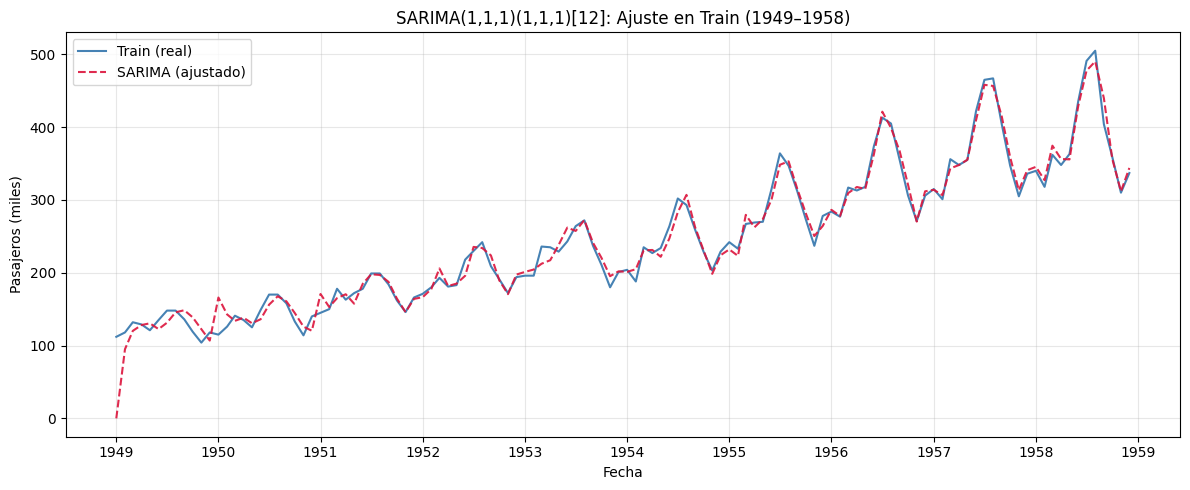

In [21]:
# Nota: las primeras observaciones son NaN por las diferenciaciones d=1, D=1
fitted_sarima = resultado_sarima.fittedvalues.dropna()
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(train_c.index, train_c['pasajeros'],
        label='Train (real)', color='steelblue', linewidth=1.5)
ax.plot(fitted_sarima.index, fitted_sarima,
        label='SARIMA (ajustado)', color='crimson', linestyle='--', alpha=0.9)
ax.set_title('SARIMA(1,1,1)(1,1,1)[12]: Ajuste en Train (1949–1958)')
ax.set_xlabel('Fecha'); ax.set_ylabel('Pasajeros (miles)')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

#### Visualización: Predicciones sobre período de prueba (Test)

In [22]:
predicciones = resultado_sarima.predict(
    start=len(train_c),
    end=len(train_c) + len(test_c) - 1,
    dynamic=False
)
predicciones.index = test_c.index

In [23]:
rmse_sarima = np.sqrt(mean_squared_error(test_c['pasajeros'], predicciones))
mae_sarima  = mean_absolute_error(test_c['pasajeros'], predicciones)
print(f"=== SARIMA(1,1,1)(1,1,1)[12] — métricas sobre test (1959–1960) ===")
print(f"RMSE = {rmse_sarima:.2f}  |  MAE = {mae_sarima:.2f}")

=== SARIMA(1,1,1)(1,1,1)[12] — métricas sobre test (1959–1960) ===
RMSE = 75.63  |  MAE = 69.90


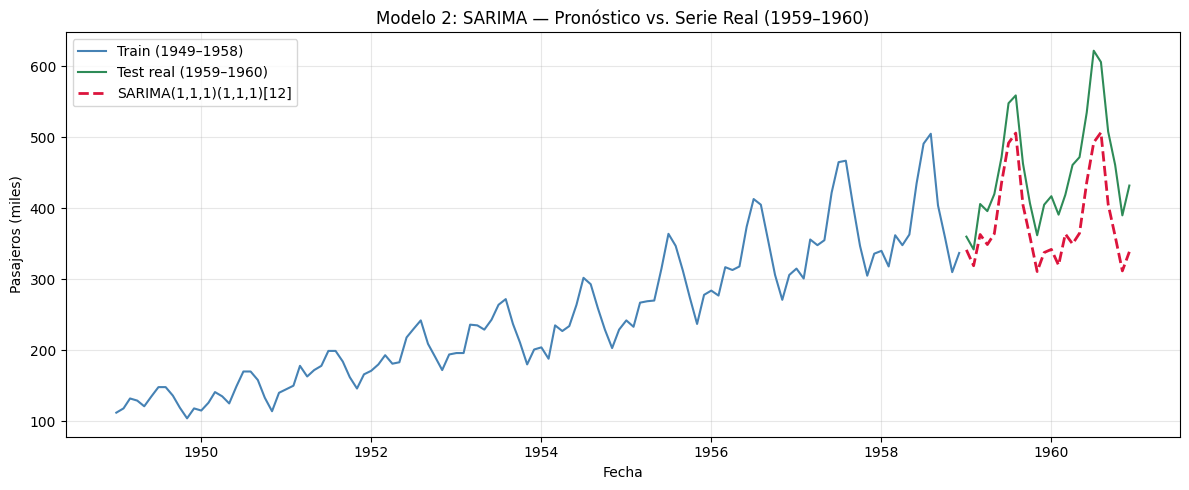

In [24]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(train_c.index, train_c['pasajeros'], label='Train (1949–1958)', color='steelblue')
ax.plot(test_c.index,  test_c['pasajeros'],  label='Test real (1959–1960)', color='seagreen')
ax.plot(predicciones.index, predicciones,
        label='SARIMA(1,1,1)(1,1,1)[12]', color='crimson', linestyle='--', linewidth=2)
ax.set_title('Modelo 2: SARIMA — Pronóstico vs. Serie Real (1959–1960)')
ax.set_xlabel('Fecha'); ax.set_ylabel('Pasajeros (miles)')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

---

### Modelo 3: AutoARIMA

>Automatiza la búsqueda de los órdenes óptimos de SARIMA minimizando AIC.

**Descripción:**  
`auto_arima` (librería `pmdarima`) explora sistemáticamente combinaciones de parámetros SARIMA mediante el algoritmo stepwise de Hyndman-Khandakar y elige la que minimiza el AIC. Es un nivel de complejidad *conceptual* mayor que SARIMA porque además del modelo en sí involucra el proceso de selección estadística.

**Justificación de uso:** Permite evaluar si la selección automática de órdenes mejora al SARIMA(1,1,1)(1,1,1)[12] configurado manualmente.

#### Configuración y selección de parámetros

- `seasonal=True, m=12` → incluye diferenciación estacional anual en la búsqueda
- `stepwise=True` → búsqueda guiada (no exhaustiva)
- `information_criterion='aic'` → criterio de selección del mejor modelo

#### Búsqueda de parámetros y entrenamiento

In [25]:
print("Buscando el mejor modelo SARIMA por AIC (puede tardar ~10 seg)...")
modelo_auto = auto_arima(
    train_c['pasajeros'],
    seasonal=True,
    m=12,
    stepwise=True,
    information_criterion='aic',
    trace=False,
    suppress_warnings=True,
    error_action='ignore'
)
print(f"\nMejor modelo encontrado: SARIMA{modelo_auto.order}x{modelo_auto.seasonal_order}")
print(f"AIC = {modelo_auto.aic():.2f}")
print(modelo_auto.summary())

pred_auto_arr = modelo_auto.predict(n_periods=24)
pred_auto = pd.Series(pred_auto_arr, index=test_c.index)

rmse_auto = np.sqrt(mean_squared_error(test_c['pasajeros'], pred_auto))
mae_auto  = mean_absolute_error(test_c['pasajeros'], pred_auto)
print(f"\n=== AutoARIMA — métricas sobre test (1959–1960) ===")
print(f"RMSE = {rmse_auto:.2f}  |  MAE = {mae_auto:.2f}")

Buscando el mejor modelo SARIMA por AIC (puede tardar ~10 seg)...

Mejor modelo encontrado: SARIMA(2, 0, 0)x(0, 1, 0, 12)
AIC = 808.86
                                     SARIMAX Results                                      
Dep. Variable:                                  y   No. Observations:                  120
Model:             SARIMAX(2, 0, 0)x(0, 1, 0, 12)   Log Likelihood                -400.431
Date:                            Sat, 13 Jun 2026   AIC                            808.863
Time:                                    14:48:00   BIC                            819.592
Sample:                                01-01-1949   HQIC                           813.213
                                     - 12-01-1958                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------

#### Visualización: Ajuste en datos de entrenamiento (Train)

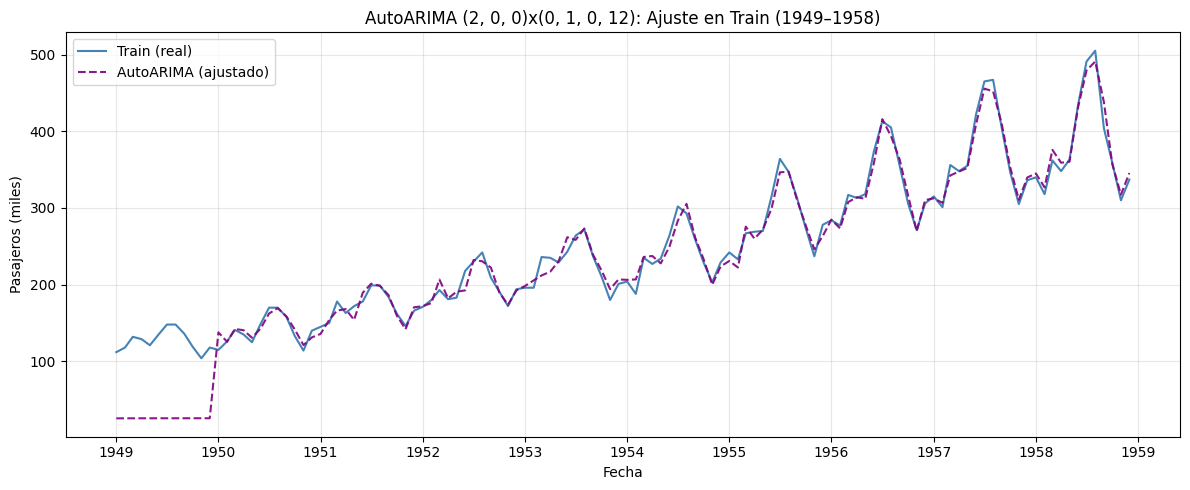

In [26]:
fitted_auto = pd.Series(modelo_auto.predict_in_sample(), index=train_c.index)
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(train_c.index, train_c['pasajeros'],
        label='Train (real)', color='steelblue', linewidth=1.5)
ax.plot(train_c.index, fitted_auto,
        label='AutoARIMA (ajustado)', color='purple', linestyle='--', alpha=0.9)
ax.set_title(f'AutoARIMA {modelo_auto.order}x{modelo_auto.seasonal_order}: Ajuste en Train (1949–1958)')
ax.set_xlabel('Fecha'); ax.set_ylabel('Pasajeros (miles)')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

#### Visualización: Predicciones sobre período de prueba (Test)

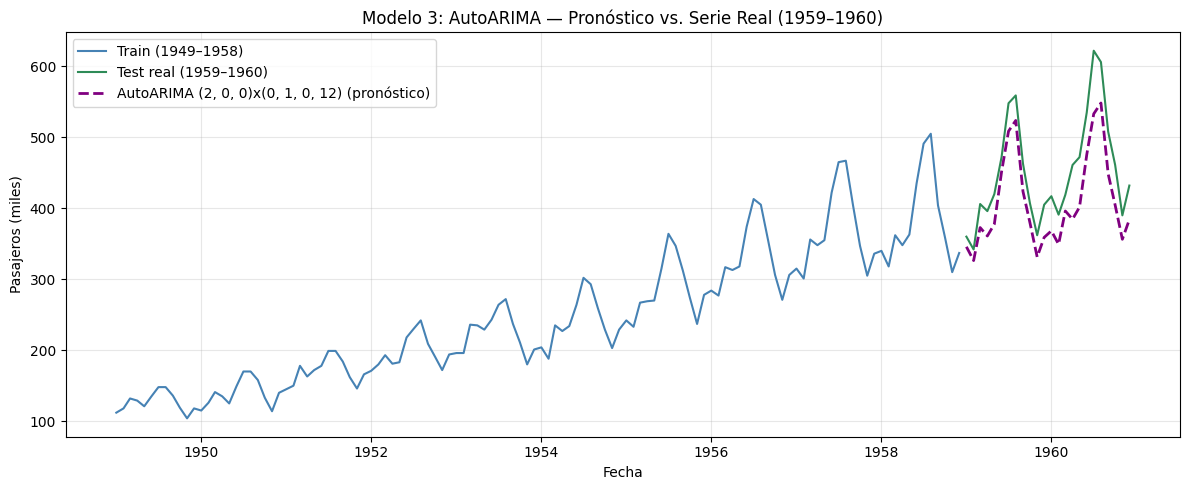

In [27]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(train_c.index, train_c['pasajeros'], label='Train (1949–1958)', color='steelblue')
ax.plot(test_c.index,  test_c['pasajeros'],  label='Test real (1959–1960)', color='seagreen')
ax.plot(pred_auto.index, pred_auto,
        label=f'AutoARIMA {modelo_auto.order}x{modelo_auto.seasonal_order} (pronóstico)',
        color='purple', linestyle='--', linewidth=2)
ax.set_title('Modelo 3: AutoARIMA — Pronóstico vs. Serie Real (1959–1960)')
ax.set_xlabel('Fecha'); ax.set_ylabel('Pasajeros (miles)')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

---

## 4. Comparación y Selección

### Tabla comparativa de métricas (Test: 1959–1960)

Las métricas se calculan sobre el período de prueba que ningún modelo vio durante el entrenamiento. **Se resalta en verde** la mejor (menor) métrica en cada columna.

- **RMSE:** penaliza errores grandes desproporcionadamente (sensible a picos)
- **MAE:** error promedio absoluto en las mismas unidades que la variable (miles de pasajeros)

### Gráfico comparativo: los 3 modelos vs. serie real

In [28]:
resultados = pd.DataFrame({
    'Modelo': [
        'Holt-Winters',
        'SARIMA(1,1,1)(1,1,1)[12]',
        f'AutoARIMA {modelo_auto.order}x{modelo_auto.seasonal_order}',
    ],
    'RMSE': [rmse_hw, rmse_sarima, rmse_auto],
    'MAE':  [mae_hw,  mae_sarima,  mae_auto]
}).set_index('Modelo')

display(
    resultados.style
    .highlight_min(subset=['RMSE', 'MAE'], color='#90EE90', axis=0)
    .format({'RMSE': '{:.2f}', 'MAE': '{:.2f}'})
)

,RMSE,MAE
Modelo,,
Holt-Winters,32.49,28.98
"SARIMA(1,1,1)(1,1,1)[12]",75.63,69.90
"AutoARIMA (2, 0, 0)x(0, 1, 0, 12)",47.23,43.46


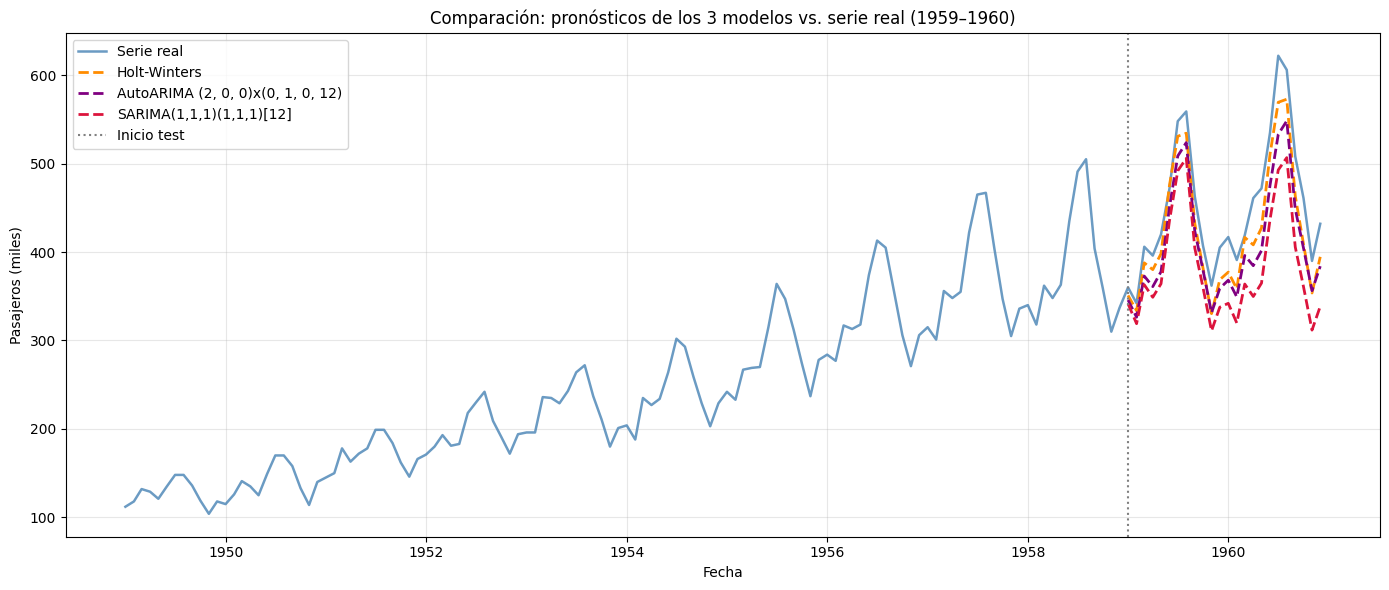

In [29]:
fig, ax = plt.subplots(figsize=(14, 6))

# Serie real completa
ax.plot(df.index, df['pasajeros'],
        label='Serie real', color='steelblue', linewidth=1.8, alpha=0.8)

# Predicciones de los 3 modelos (solo período test)
ax.plot(pred_hw.index,      pred_hw,
        label='Holt-Winters', color='darkorange', linestyle='--', linewidth=2)
ax.plot(pred_auto.index,    pred_auto,
        label=f'AutoARIMA {modelo_auto.order}x{modelo_auto.seasonal_order}',
        color='purple', linestyle='--', linewidth=2)
ax.plot(predicciones.index, predicciones,
        label='SARIMA(1,1,1)(1,1,1)[12]', color='crimson', linestyle='--', linewidth=2)

# Línea vertical separando train y test
ax.axvline(x=test_c.index[0], color='gray', linestyle=':', linewidth=1.5, label='Inicio test')

ax.set_title('Comparación: pronósticos de los 3 modelos vs. serie real (1959–1960)')
ax.set_xlabel('Fecha'); ax.set_ylabel('Pasajeros (miles)')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---

## 5. Modelos con Transformación Logarítmica

SARIMA y AutoARIMA son modelos lineales (aditivos): asumen que las componentes se *suman*. En AirPassengers la relación es multiplicativa — la amplitud del ciclo estacional escala con la tendencia. La transformación logarítmica convierte esa multiplicación en suma:

`Xt = T × S × ε  →  log(Xt) = log(T) + log(S) + log(ε)`

Las predicciones se obtienen en escala log y se transforman de vuelta con `exp()` para comparar con la serie original.

---

### SARIMA-Log

Se aplican los mismos parámetros `(1,1,1)(1,1,1)[12]` sobre `log(pasajeros)`.

#### Entrenamiento

In [30]:
# Log-transform de la serie
log_train = np.log(train_c['pasajeros'])

# SARIMA sobre log(pasajeros) con los mismos parámetros
modelo_sarima_log = SARIMAX(
    log_train,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)
resultado_sarima_log = modelo_sarima_log.fit(disp=False)
print("=== SARIMA-Log — entrenado ===")
print(resultado_sarima_log.summary().tables[1])

# Predicción en escala log → back-transform con exp()
pred_sarima_log_raw = resultado_sarima_log.predict(
    start=len(train_c),
    end=len(train_c) + len(test_c) - 1,
    dynamic=False
)
pred_sarima_log = np.exp(pred_sarima_log_raw)
pred_sarima_log.index = test_c.index

rmse_sarima_log = np.sqrt(mean_squared_error(test_c['pasajeros'], pred_sarima_log))
mae_sarima_log  = mean_absolute_error(test_c['pasajeros'], pred_sarima_log)
print(f"\n=== SARIMA-Log — métricas sobre test ===")
print(f"RMSE = {rmse_sarima_log:.2f}  |  MAE = {mae_sarima_log:.2f}")
print(f"Sin log → RMSE = {rmse_sarima:.2f}  |  MAE = {mae_sarima:.2f}")

/Users/cespinola/Desktop/Maestría/13_Analisis de series de tiempo/.venv_tp/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/cespinola/Desktop/Maestría/13_Analisis de series de tiempo/.venv_tp/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


=== SARIMA-Log — entrenado ===
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0518      0.255      0.203      0.839      -0.448       0.552
ma.L1         -0.4654      0.235     -1.981      0.048      -0.926      -0.005
ar.S.L12      -0.3800      0.182     -2.094      0.036      -0.736      -0.024
ma.S.L12      -0.1078      0.224     -0.481      0.631      -0.547       0.332
sigma2         0.0015      0.000      7.235      0.000       0.001       0.002

=== SARIMA-Log — métricas sobre test ===
RMSE = 48.22  |  MAE = 43.70
Sin log → RMSE = 75.63  |  MAE = 69.90


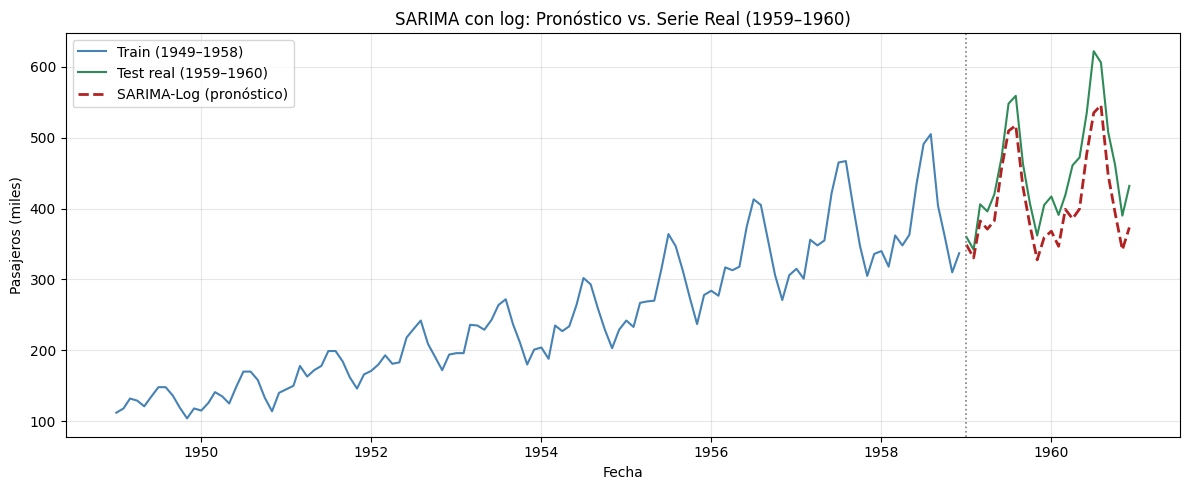

In [31]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(train_c.index, train_c['pasajeros'], label='Train (1949–1958)', color='steelblue')
ax.plot(test_c.index,  test_c['pasajeros'],  label='Test real (1959–1960)', color='seagreen')
ax.plot(pred_sarima_log.index, pred_sarima_log,
        label='SARIMA-Log (pronóstico)', color='firebrick', linestyle='--', linewidth=2)
ax.axvline(x=test_c.index[0], color='gray', linestyle=':', linewidth=1.2)
ax.set_title('SARIMA con log: Pronóstico vs. Serie Real (1959–1960)')
ax.set_xlabel('Fecha'); ax.set_ylabel('Pasajeros (miles)')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

---

### AutoARIMA-Log

Se aplica `auto_arima` sobre `log(pasajeros)`. El modelo encontrado puede diferir del Modelo 3 (serie original) dado que la distribución del error cambia con la transformación.

#### Búsqueda de parámetros y entrenamiento

In [ ]:
log_train = np.log(train_c['pasajeros'])   # ya definido en la celda anterior, re-declarado por claridad

print("Buscando el mejor modelo AutoARIMA sobre log(pasajeros)...")
modelo_auto_log = auto_arima(
    log_train,
    seasonal=True,
    m=12,
    stepwise=True,
    information_criterion='aic',
    trace=False,
    suppress_warnings=True,
    error_action='ignore'
)
print(f"\nMejor modelo encontrado: SARIMA{modelo_auto_log.order}x{modelo_auto_log.seasonal_order}")
print(f"AIC = {modelo_auto_log.aic():.2f}")

pred_auto_log_raw = modelo_auto_log.predict(n_periods=24)
pred_auto_log = np.exp(pd.Series(pred_auto_log_raw, index=test_c.index))

rmse_auto_log = np.sqrt(mean_squared_error(test_c['pasajeros'], pred_auto_log))
mae_auto_log  = mean_absolute_error(test_c['pasajeros'], pred_auto_log)
print(f"\n=== AutoARIMA-Log — métricas sobre test ===")
print(f"RMSE = {rmse_auto_log:.2f}  |  MAE = {mae_auto_log:.2f}")
print(f"Sin log → RMSE = {rmse_auto:.2f}  |  MAE = {mae_auto:.2f}")

Buscando el mejor modelo AutoARIMA sobre log(pasajeros)...

Mejor modelo encontrado: SARIMA(2, 0, 0)x(0, 1, 1, 12)
AIC = -393.54

=== AutoARIMA-Log — métricas sobre test ===
RMSE = 14.07  |  MAE = 10.62
Sin log → RMSE = 47.23  |  MAE = 43.46


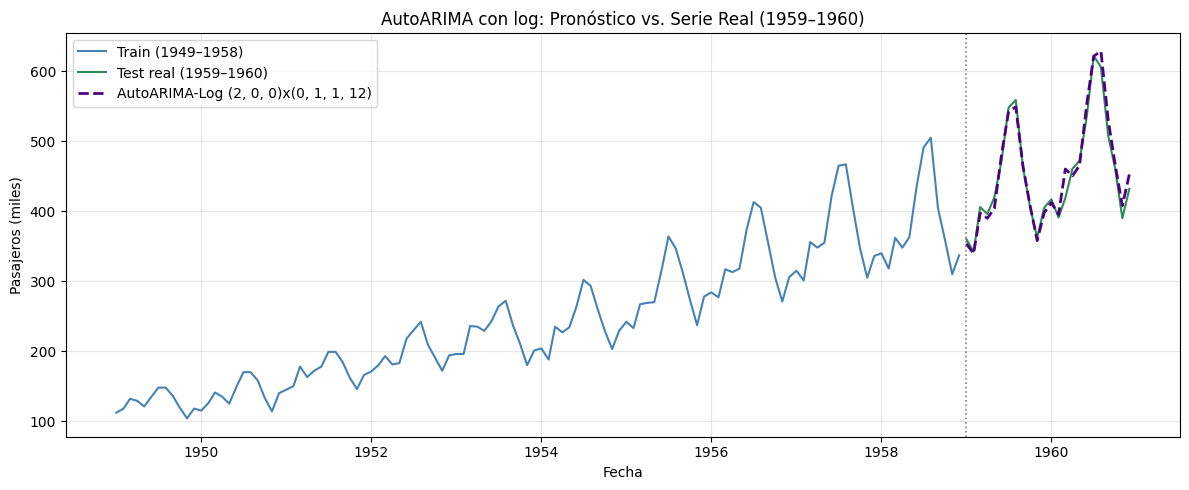

In [33]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(train_c.index, train_c['pasajeros'], label='Train (1949–1958)', color='steelblue')
ax.plot(test_c.index,  test_c['pasajeros'],  label='Test real (1959–1960)', color='seagreen')
ax.plot(pred_auto_log.index, pred_auto_log,
        label=f'AutoARIMA-Log {modelo_auto_log.order}x{modelo_auto_log.seasonal_order}',
        color='indigo', linestyle='--', linewidth=2)
ax.axvline(x=test_c.index[0], color='gray', linestyle=':', linewidth=1.2)
ax.set_title('AutoARIMA con log: Pronóstico vs. Serie Real (1959–1960)')
ax.set_xlabel('Fecha'); ax.set_ylabel('Pasajeros (miles)')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

---

## 6. Comparación con Transformación Logarítmica

### 6.a — Impacto de la transformación log por modelo

Comparación directa entre la versión con y sin log-transform para SARIMA y AutoARIMA. La línea punteada es la versión sin log; la discontinua es la versión con log.

In [34]:
resultados_completo = pd.DataFrame({
    'Modelo': [
        'Holt-Winters',
        'SARIMA (sin log)',
        'SARIMA-Log (con log)',
        f'AutoARIMA {modelo_auto.order}x{modelo_auto.seasonal_order} (sin log)',
        f'AutoARIMA-Log {modelo_auto_log.order}x{modelo_auto_log.seasonal_order} (con log)',
    ],
    'RMSE': [rmse_hw,    rmse_sarima,     rmse_sarima_log,  rmse_auto,     rmse_auto_log],
    'MAE':  [mae_hw,     mae_sarima,      mae_sarima_log,   mae_auto,      mae_auto_log]
}).set_index('Modelo')

display(
    resultados_completo.style
    .highlight_min(subset=['RMSE', 'MAE'], color='#90EE90', axis=0)
    .format({'RMSE': '{:.2f}', 'MAE': '{:.2f}'})
)

,RMSE,MAE
Modelo,,
Holt-Winters,32.49,28.98
SARIMA (sin log),75.63,69.90
SARIMA-Log (con log),48.22,43.70
"AutoARIMA (2, 0, 0)x(0, 1, 0, 12) (sin log)",47.23,43.46
"AutoARIMA-Log (2, 0, 0)x(0, 1, 1, 12) (con log)",14.07,10.62


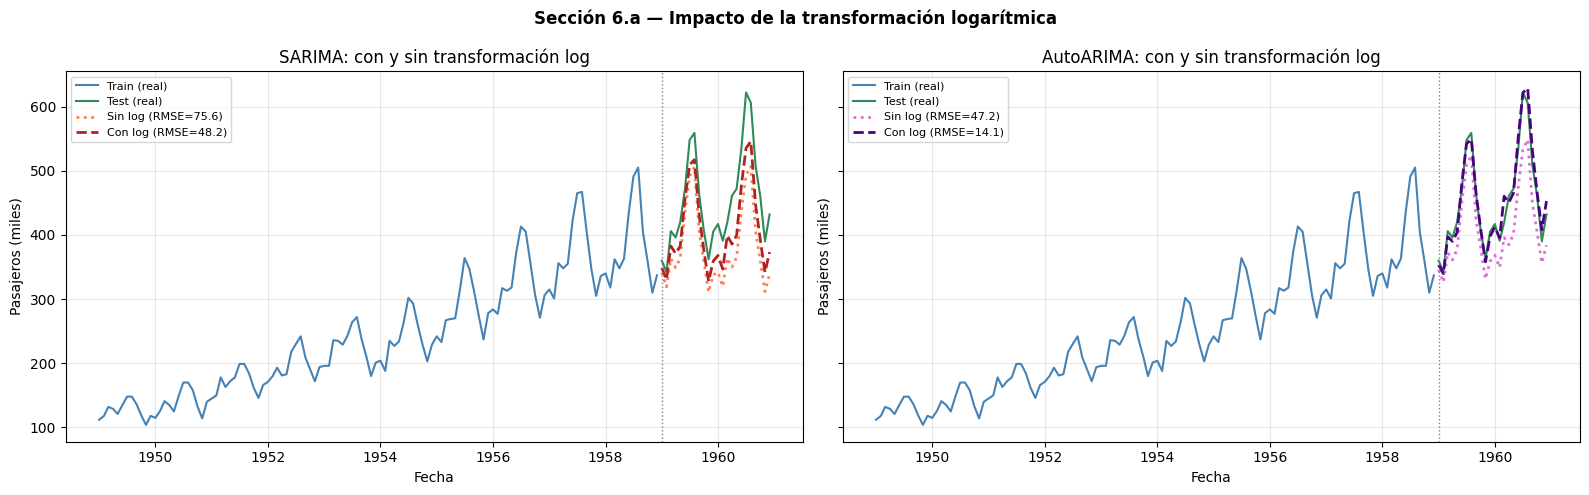

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

for ax, (title, pred_sin, pred_con, rmse_sin, rmse_con, color_sin, color_con) in zip(axes, [
    ('SARIMA: con y sin transformación log',
     predicciones, pred_sarima_log, rmse_sarima, rmse_sarima_log, 'coral', 'firebrick'),
    ('AutoARIMA: con y sin transformación log',
     pred_auto, pred_auto_log, rmse_auto, rmse_auto_log, 'orchid', 'indigo')
]):
    ax.plot(train_c.index, train_c['pasajeros'], label='Train (real)', color='steelblue', linewidth=1.5)
    ax.plot(test_c.index,  test_c['pasajeros'],  label='Test (real)', color='seagreen', linewidth=1.5)
    ax.plot(pred_sin.index, pred_sin,
            label=f'Sin log (RMSE={rmse_sin:.1f})', color=color_sin, linestyle=':', linewidth=2)
    ax.plot(pred_con.index, pred_con,
            label=f'Con log (RMSE={rmse_con:.1f})', color=color_con, linestyle='--', linewidth=2)
    ax.axvline(x=test_c.index[0], color='gray', linestyle=':', linewidth=1)
    ax.set_title(title); ax.set_xlabel('Fecha'); ax.set_ylabel('Pasajeros (miles)')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.suptitle('Sección 6.a — Impacto de la transformación logarítmica', fontweight='bold')
plt.tight_layout(); plt.show()

### 6.b — Modelos log vs. Holt-Winters

Tabla completa de los 5 modelos y gráfico comparativo. Holt-Winters captura la estacionalidad multiplicativa de forma nativa; la transformación log permite que SARIMA y AutoARIMA la aproximen.

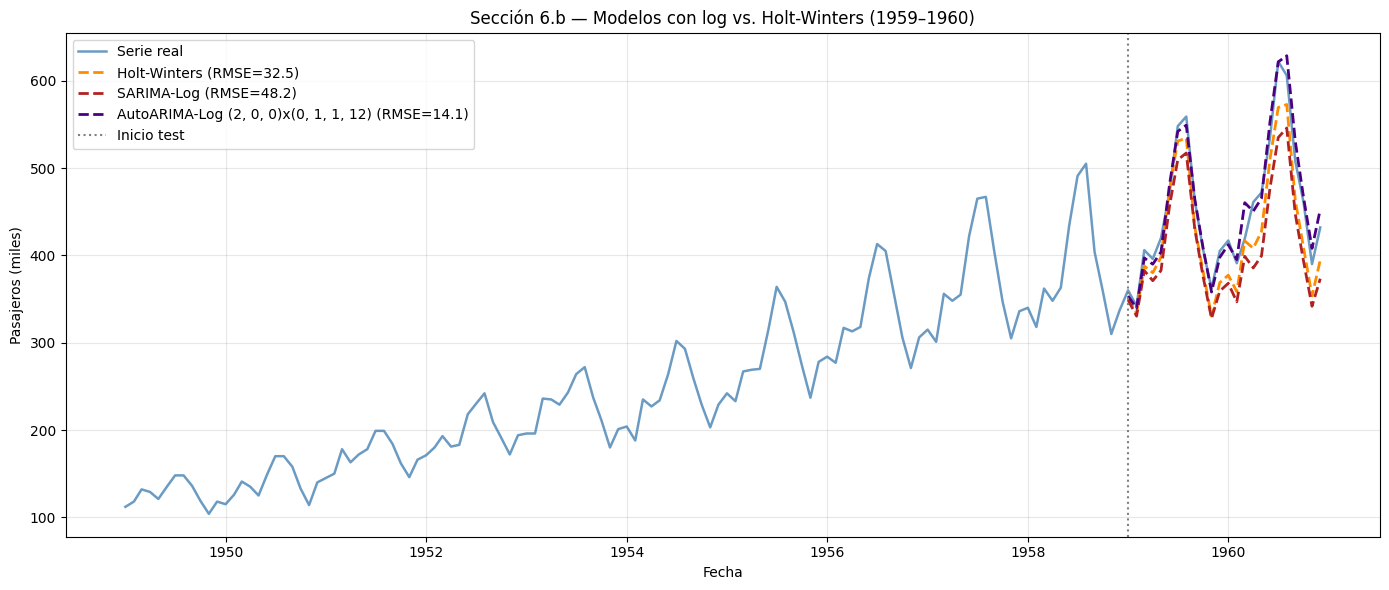

In [36]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(df.index, df['pasajeros'],
        label='Serie real', color='steelblue', linewidth=1.8, alpha=0.8)
ax.plot(pred_hw.index, pred_hw,
        label=f'Holt-Winters (RMSE={rmse_hw:.1f})',
        color='darkorange', linestyle='--', linewidth=2)
ax.plot(pred_sarima_log.index, pred_sarima_log,
        label=f'SARIMA-Log (RMSE={rmse_sarima_log:.1f})',
        color='firebrick', linestyle='--', linewidth=2)
ax.plot(pred_auto_log.index, pred_auto_log,
        label=f'AutoARIMA-Log {modelo_auto_log.order}x{modelo_auto_log.seasonal_order} (RMSE={rmse_auto_log:.1f})',
        color='indigo', linestyle='--', linewidth=2)
ax.axvline(x=test_c.index[0], color='gray', linestyle=':', linewidth=1.5, label='Inicio test')
ax.set_title('Sección 6.b — Modelos con log vs. Holt-Winters (1959–1960)')
ax.set_xlabel('Fecha'); ax.set_ylabel('Pasajeros (miles)')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()